In [2]:
import numpy as np
import pandas as pd
import math
import networkx as nx
import matplotlib.pyplot as plt
import random
from community import community_louvain  # python-louvain kütüphanesi gerekli
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import scipy.linalg as la
from statistics import mode
import numpy as np
import leidenalg
import igraph as ig
from collections import defaultdict
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from scipy.special import comb  # binom için
from collections import defaultdict
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.centrality import girvan_newman
from itertools import islice


In [4]:


#df = pd.read_csv('25usa.csv')
#df =  pd.read_csv("25Asia.csv")
#df = pd.read_csv('25Africa.csv')
#df = pd.read_csv('25europa.csv')



df =  pd.read_csv('25all.csv')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6932\2855326147.py:8: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv('25all.csv')


# GenAI keywords

In [10]:
keywords = [
    "LangChain", "LLM Prompt Engineering", "Claude", "OpenAI API", "OpenAI",
    "GPT-4", "Prompt Engineering", "GPT-4 API", "GPT API", "DALL-E API",
    "ChatGPT API", "Azure OpenAI Service", "DALL-E", "Gemini", "Gemini API",
    "ChatGPT API integration", "Llama", "Llama API", "Llama 3", "Llama 4",
    "LLM Prompt", "Conversational AI", "Midjourney AI", "AI-Genererated Image",
    "Image Prompt", "Midjourney Prompt", "Image Prompt Engineering",
    "AI Image Editing", "AI Video Generation", "AI Image Generation",
    "Generative AI Prompt Engineering", "AI Text-to-Speech", "Generative AI"
]

# Tüm DataFrame içinde bu kelimeleri "LLM 2025" ile değiştir
for word in keywords:
    df = df.replace(word, "GenAI 2025", regex=True)




In [12]:
df

,Keywords,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Skill_11,Skill_12
0,Audio Post Production\r\nAudio Editing\r\nPodc...,Audio Post Production,Audio Editing,Podcast,Sound Mixing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pro Forma Statement\r\nFinancial Modeling\r\nF...,Pro Forma Statement,Financial Modeling,Financial Projection,Microsoft Excel,Financial Planning,Financial Analysis,NaN,NaN,NaN,NaN,NaN,NaN
2,Adobe Premiere Pro\r\nVideo Production\r\nPhot...,Adobe Premiere Pro,Video Production,Photography,Videography,People,Video Editing,Video Post-Editing,NaN,NaN,NaN,NaN,NaN
3,Graphic Design\r\nSocial Media Imagery\r\nYouTube,Graphic Design,Social Media Imagery,YouTube,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Graphic Design\r\nAdobe Illustrator\r\nAdobe P...,Graphic Design,Adobe Illustrator,Adobe Photoshop,Infographic,Adobe InDesign,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69242,Microsoft Excel\r\nData Analysis\r\nStatistics...,Microsoft Excel,Data Analysis,Statistics,Data Visualization,Qualitative Research,Report Writing,NaN,NaN,NaN,NaN,NaN,NaN
69243,WordPress\r\nWeb Development\r\nWeb Design\r\n...,WordPress,Web Development,Web Design,CSS,HTML,PHP,JavaScript,HTML5,WooCommerce,NaN,NaN,NaN
69244,Photography\r\nPhoto Retouching\r\nPhoto Editi...,Photography,Photo Retouching,Photo Editing,Adobe Photoshop,Product Photography,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69245,WordPress\r\nWeb Design\r\nElementor\r\nCSS,WordPress,Web Design,Elementor,CSS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
keywords = ["GenAI 2025 API"]
   


# Tüm DataFrame içinde bu kelimeleri "LLM 2025" ile değiştir
for word in keywords:
    df = df.replace(word, "GenAI 2025", regex=True)


In [16]:
from collections import Counter

# Kolon isimlerini string olarak kontrol et
skill_columns = [col for col in df.columns if str(col).startswith("Skill_")]

# Tüm becerileri topla
all_skills = []
for col in skill_columns:
    all_skills.extend(df[col].dropna().tolist())

# Sayım
skill_counts = Counter(all_skills)

# En çoktan en aza sırala
most_common_skills = skill_counts.most_common()

# Sonuçları yazdır
print("🔝 En sık geçen kalifikasyonlar:")
for skill, count in most_common_skills:

    print(f"{skill}: {count} time")


🔝 En sık geçen kalifikasyonlar:
Graphic Design: 7044 time
Web Development: 6802 time
JavaScript: 5901 time
Web Design: 5568 time
WordPress: 5436 time
Lead Generation: 5074 time
Social Media Marketing: 4902 time
Video Editing: 4428 time
PHP: 4355 time
Adobe Photoshop: 4334 time
API: 4237 time
HTML: 4011 time
Facebook: 3752 time
Data Entry: 3571 time
Search Engine Optimization: 3560 time
Marketing Strategy: 3251 time
English: 3223 time
CSS: 3204 time
Adobe Illustrator: 3181 time
Content Writing: 3161 time
Adobe Premiere Pro: 2994 time
Shopify: 2879 time
Instagram: 2813 time
Adobe After Effects: 2774 time
Python: 2681 time
Video Production: 2653 time
Microsoft Excel: 2628 time
Mobile App Development: 2368 time
SEO Keyword Research: 2260 time
Video Post-Editing: 2048 time
Social Media Management: 2035 time
Administrative Support: 1843 time
Data Scraping: 1797 time
Customer Service: 1684 time
SEO Backlinking: 1671 time
Illustration: 1623 time
Flutter: 1612 time
List Building: 1582 time
Andr

In [19]:
count = df.astype(str).apply(lambda x: x.str.count("GenAI 2025")).sum().sum()
print(f'"GenAI 2025" occurs {count} time.')
print("total skills",  len(skill_counts))

"GenAI 2025" occurs 2380 time.
total skills 1221


In [23]:
filtered_df = df[df.astype(str).apply(lambda row: row.str.contains("GenAI 2025")).any(axis=1)]

# Sonuçları göster
filtered_df

,Keywords,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Skill_11,Skill_12
5549,English\r\nGenAI 2025\r\nGenAI 2025\r\nQA Testing,English,GenAI 2025,GenAI 2025,QA Testing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5597,English\r\nGenAI 2025\r\nGenAI 2025\r\nQA Testing,English,GenAI 2025,GenAI 2025,QA Testing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5646,English\r\nGenAI 2025\r\nGenAI 2025\r\nQA Testing,English,GenAI 2025,GenAI 2025,QA Testing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5694,English\r\nGenAI 2025\r\nGenAI 2025\r\nQA Testing,English,GenAI 2025,GenAI 2025,QA Testing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5743,English\r\nGenAI 2025\r\nGenAI 2025\r\nQA Testing,English,GenAI 2025,GenAI 2025,QA Testing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69019,GenAI 2025\r\nJavaScript\r\nCharacter Animation,GenAI 2025,JavaScript,Character Animation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69069,GenAI 2025\r\nJavaScript\r\nCharacter Animation,GenAI 2025,JavaScript,Character Animation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69120,GenAI 2025\r\nJavaScript\r\nCharacter Animation,GenAI 2025,JavaScript,Character Animation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69172,GenAI 2025\r\nJavaScript\r\nCharacter Animation,GenAI 2025,JavaScript,Character Animation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
print( "toplam :",  len(df), "geçen", len(filtered_df),  "frekans", len(filtered_df) / len(df))

toplam : 69247 geçen 1020 frekans 0.014729879994801218


973 kez çıkıyor toplam 323054  tane 2025 keyword arasından buda frekasn olarak 0,0028 lik bir değer göstermektedir. 


In [28]:
Network = pd.DataFrame(most_common_skills, columns=["Skill", "Frekans"])

# Sonuç kontrolü
print(Network.head())

             Skill  Frekans
0   Graphic Design     7044
1  Web Development     6802
2       JavaScript     5901
3       Web Design     5568
4        WordPress     5436


In [30]:
Network["ID"]=range(len(Network))
Network

,Skill,Frekans,ID
0,Graphic Design,7044,0
1,Web Development,6802,1
2,JavaScript,5901,2
3,Web Design,5568,3
4,WordPress,5436,4
...,...,...,...
1216,Structural Drawing,1,1216
1217,Social Media Audience Research,1,1217
1218,Decision Making,1,1218
1219,Receptionist Skills,1,1219


In [32]:
# 1. Skill isimleriyle tam sayı (int) ID'leri eşleştiren sözlük oluştur
skill_to_id = dict(zip(Network["Skill"], Network["ID"].astype(int).astype(str)))

# 2. Skill kolonlarını seç
skill_columns = [col for col in df.columns if str(col).startswith("Skill_")]

# 3. Her hücredeki beceriyi ID ile değiştir ve NaN yerine boş string ver
for col in skill_columns:
    df[col] = df[col].map(skill_to_id).fillna('').astype(str).replace('nan', '')

In [34]:
df

,Keywords,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10,Skill_11,Skill_12
0,Audio Post Production\r\nAudio Editing\r\nPodc...,392,135,322,455,,,,,,,,
1,Pro Forma Statement\r\nFinancial Modeling\r\nF...,898,264,608,26,906,120,,,,,,
2,Adobe Premiere Pro\r\nVideo Production\r\nPhot...,20,25,126,86,830,7,29,,,,,
3,Graphic Design\r\nSocial Media Imagery\r\nYouTube,0,234,197,,,,,,,,,
4,Graphic Design\r\nAdobe Illustrator\r\nAdobe P...,0,18,9,133,89,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69242,Microsoft Excel\r\nData Analysis\r\nStatistics...,26,46,106,116,413,377,,,,,,
69243,WordPress\r\nWeb Development\r\nWeb Design\r\n...,4,1,3,17,11,8,2,92,134,,,
69244,Photography\r\nPhoto Retouching\r\nPhoto Editi...,126,298,94,9,186,,,,,,,
69245,WordPress\r\nWeb Design\r\nElementor\r\nCSS,4,3,207,17,,,,,,,,


In [36]:
skill_columns = [col for col in df.columns if str(col).startswith("Skill_")]

# Yeni bir kolon oluştur: Tüm Skill_ID'leri virgül ile birleştir
df["Skill_ID_List"] = df[skill_columns].apply(
    lambda row: ",".join([str(val) for val in row if val != '']), axis=1
)
# Sonucu göster
print(df[["Skill_ID_List"]].head())

            Skill_ID_List
0         392,135,322,455
1  898,264,608,26,906,120
2   20,25,126,86,830,7,29
3               0,234,197
4           0,18,9,133,89


In [38]:
data = df["Skill_ID_List"].dropna().tolist()

In [40]:
data= [row for row in data if any(c not in ' \t\n\r' for c in row)]

In [42]:
# Kenar ağırlıklarını saklamak için sözlük
edge_weights = {}

for row in data:
    # Satırdaki düğümleri al (tekrarları ve boşlukları temizle)
    row_nodes = [int(node.strip()) for node in row.split(",")]
    
    # Tüm düğüm çiftleri için kenar oluştur (fully connected)
    for i in range(len(row_nodes)):
        for j in range(i + 1, len(row_nodes)):
            # Kenarı sıralı şekilde sakla (yönlü olmayan graf)
            edge = tuple(sorted((row_nodes[i], row_nodes[j])))
            
            # Kenar ağırlığını güncelle (varsa +1, yoksa 1 ata)
            if edge in edge_weights:
                edge_weights[edge] += 1
            else:
                edge_weights[edge] = 1

# Düğümleri bul (kenarlardan otomatik çıkar)
nodes = set()
for edge in edge_weights:
    nodes.add(edge[0])
    nodes.add(edge[1])

# NetworkX ağırlıklı graf oluştur
import networkx as nx
G = nx.Graph()

# Düğümleri ekle
G.add_nodes_from(nodes)

# Kenarları ve ağırlıklarını ekle
for edge, weight in edge_weights.items():
    G.add_edge(edge[0], edge[1], weight=weight)

# Graf bilgilerini yazdır
print("Düğümler:", G.nodes())
print("Kenarlar ve Ağırlıklar:")
for u, v, data in G.edges(data=True):
    print(f"{u}-{v}: weight={data['weight']}")


Düğümler: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [43]:
print(len(G.nodes))
print(len(G.edges))

1215
6471


In [46]:
skill_to_id['GenAI 2025']

'49'

In [48]:
id_to_skill = {v: k for k, v in skill_to_id.items()}

id_to_skill["49"]

'GenAI 2025'

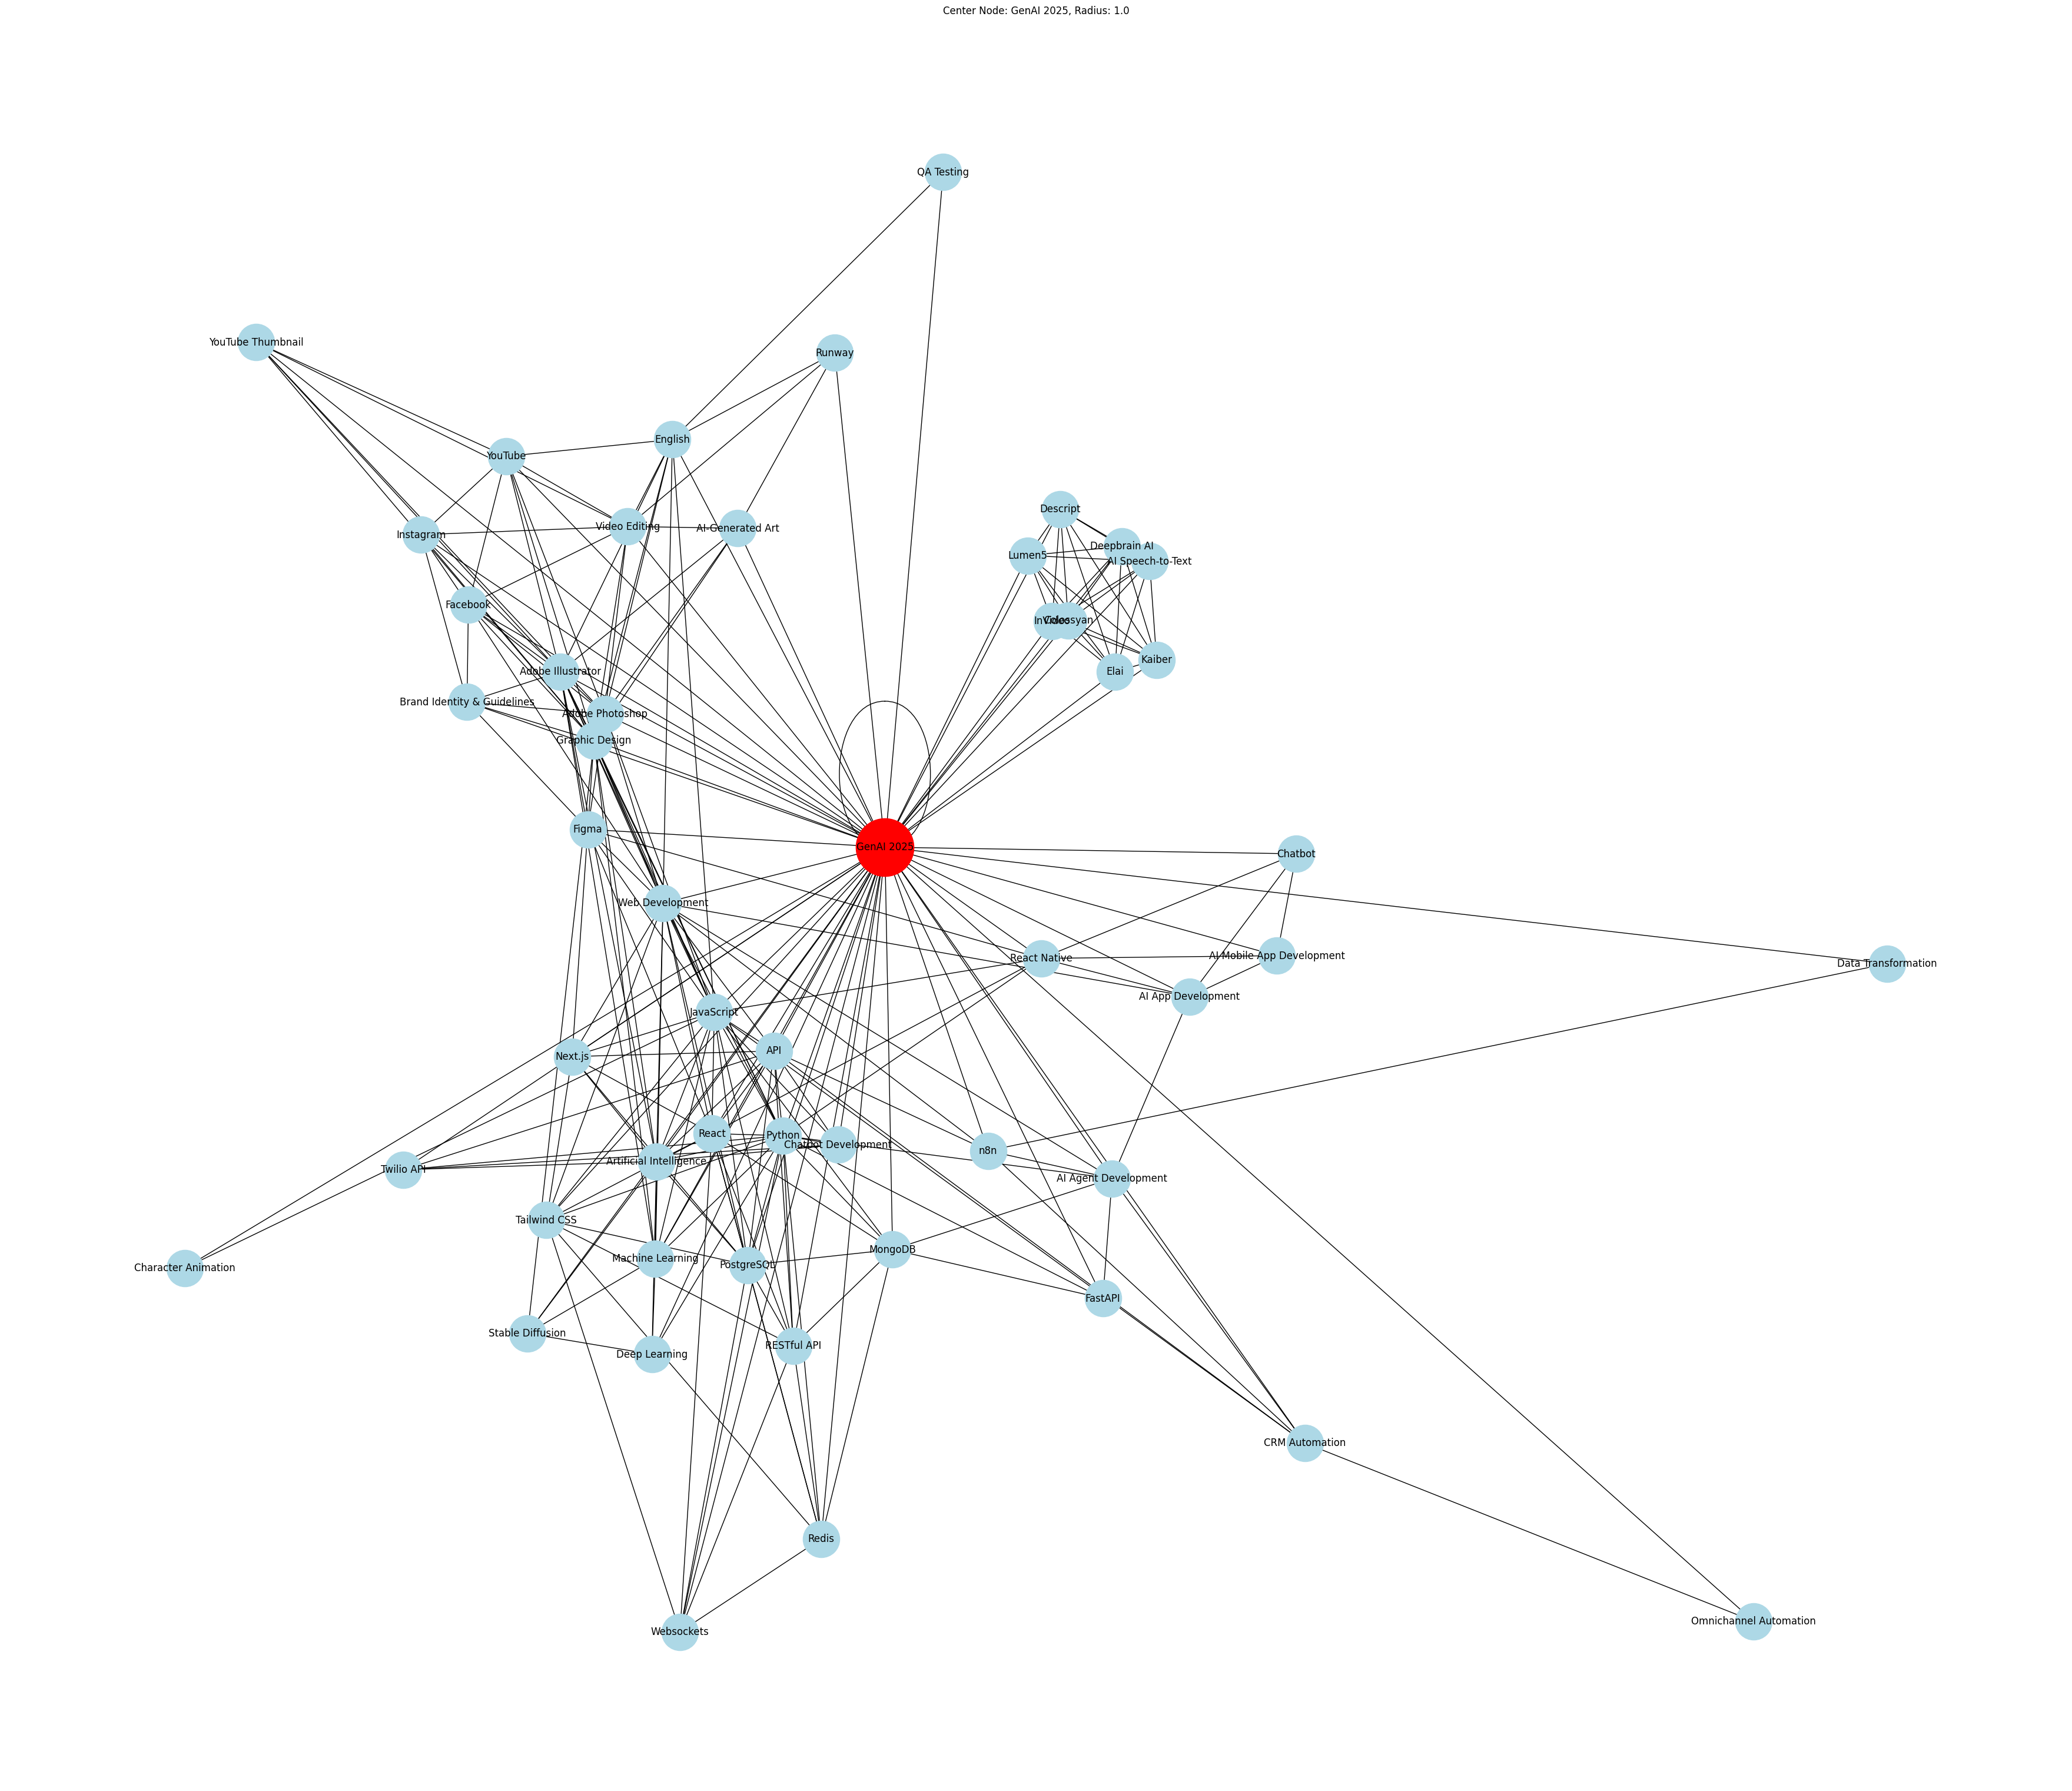

In [50]:

center_node = 49
radius = 1.00000
sub = nx.ego_graph(G ,center_node, radius=radius, undirected=True)

# 5. Düğüm Etiketlerini id_to_skill'den Al
node_labels = {node: id_to_skill[str(node)] for node in sub.nodes()}

# 6. Çizim (SADECE DÜĞÜM ETİKETLERİ)
pos = nx.spring_layout(sub, seed=16)
plt.figure(figsize=(35, 30))

# Düğümleri ve etiketlerini çiz
nx.draw(
    sub,
    pos,
    labels=node_labels,          # Özelleştirilmiş etiketler
    node_color="lightblue",
    node_size=2000,
    with_labels=True,            # Etiketleri göster
    font_size=12             # Yazı boyutu
)

# Merkez düğümü kırmızı yap
nx.draw_networkx_nodes(
    sub, 
    pos, 
    nodelist=[center_node], 
    node_color="red", 
    node_size=5000
)

plt.title(f"Center Node: {id_to_skill[str(center_node)]}, Radius: {radius}")
plt.savefig("GenAI 2025_USA.png", dpi=600, bbox_inches="tight")  # PNG olarak kaydet
plt.show()


In [51]:
len(sub.nodes)

52

In [52]:
import networkx as nx

# Leiden ile oluşturulmuş ilk alt ağı al
subgraphx = sub

# Tüm merkezilik ölçütlerini hesapla (ağırlıklı versiyonlar)
weight_param = 'weight' if 'weight' in subgraphx.edges() else None

centrality_metrics = {
    "Degree Centrality": nx.degree_centrality(subgraphx),
    "Betweenness Centrality": nx.betweenness_centrality(subgraphx, weight=weight_param),
    "Closeness Centrality": nx.closeness_centrality(subgraphx, distance=weight_param),
    "PageRank": nx.pagerank(subgraphx, weight=weight_param),
    "Authority (HITS)": nx.hits(subgraphx)[1],  # Sadece authority skorları
    "Eigenvector Centrality": nx.eigenvector_centrality(subgraphx, weight=weight_param, max_iter=1000)
}

# Her metrik için ilk 5 düğümü yazdır
for metric_name, scores in centrality_metrics.items():
    sorted_nodes = sorted(scores.items(), key=lambda x: -x[1]) # [:25]  # En yüksek 5 değer
    
    print(f"\n{metric_name} - Top 5:")
    for rank, (node, score) in enumerate(sorted_nodes, 1):
        print(f"{rank}. {node}: {[key for key, value in skill_to_id.items() if value == str(node)]}: {score:.4f}")

# Ekstra: Weighted Degree (Ağırlıklı derece) için
if weight_param:
    weighted_degrees = {node: sum(data['weight'] for _, _, data in subgraphx.edges(node, data=True)) 
                       for node in subgraphx.nodes()}
    
    print("\nWeighted Degree - Top 5:")
    for rank, (node, degree) in enumerate(sorted(weighted_degrees.items(), key=lambda x: -x[1])[:20], 1):
        print(f"{rank}. {node}: {degree:.2f}")


Degree Centrality - Top 5:
1. 49: ['GenAI 2025']: 1.0392
2. 2: ['JavaScript']: 0.4118
3. 24: ['Python']: 0.4118
4. 1: ['Web Development']: 0.3725
5. 0: ['Graphic Design']: 0.3529
6. 18: ['Adobe Illustrator']: 0.3137
7. 62: ['React']: 0.2941
8. 77: ['Artificial Intelligence']: 0.2941
9. 10: ['API']: 0.2745
10. 9: ['Adobe Photoshop']: 0.2549
11. 152: ['PostgreSQL']: 0.2549
12. 7: ['Video Editing']: 0.1961
13. 16: ['English']: 0.1961
14. 63: ['Figma']: 0.1961
15. 87: ['Machine Learning']: 0.1961
16. 399: ['Tailwind CSS']: 0.1961
17. 242: ['RESTful API']: 0.1961
18. 12: ['Facebook']: 0.1765
19. 146: ['Next.js']: 0.1765
20. 197: ['YouTube']: 0.1765
21. 252: ['MongoDB']: 0.1765
22. 271: ['AI Speech-to-Text']: 0.1569
23. 272: ['Colossyan']: 0.1569
24. 273: ['Deepbrain AI']: 0.1569
25. 275: ['Descript']: 0.1569
26. 276: ['Elai']: 0.1569
27. 277: ['InVideo']: 0.1569
28. 278: ['Kaiber']: 0.1569
29. 279: ['Lumen5']: 0.1569
30. 546: ['Redis']: 0.1569
31. 182: ['AI Agent Development']: 0.1569
32. 